#**Imports & Settings**

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import os

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve
)

import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')


RANDOM_STATE = 42
TARGET = 'Leak_No_Leak'

DATA_PATH = '/content/VIEW_2_ML_dataset_REGENERATED_FINAL_FIXED_HISTORY (1).csv'

OUTPUT_DIR = '/content/xgboost_artifacts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Settings loaded.")

Settings loaded.


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (100000, 80)

Columns:
['Asset_ID', 'Asset_Type', 'Pipe_Material', 'Pipe_Diameter_cm', 'Pipe_Length_m', 'Pipe_Depth_m', 'Frost_Depth_m', 'Installation_Year', 'Installation_Date', 'Pipe_Age_Years', 'Condition_Score', 'Criticality', 'Criticality_Score', 'Lined', 'Undersized', 'Shallow_Main', 'Oversized', 'Cleaned', 'Pressure_Sensor_ID', 'Pressure', 'Pressure_Unit', 'Flow_Sensor_ID', 'Flow_Rate', 'Flow_Unit', 'Pressure_Deviation', 'Flow_Deviation', 'Pressure_Change_Rate', 'Flow_Change_Rate', 'Pressure_Flow_Ratio', 'Temperature_C', 'pH', 'TDS_mg_L', 'Turbidity_NTU', 'Dissolved_Oxygen_mg_L', 'Conductivity_umhos_cm', 'BOD_mg_L', 'Nitrate_Nitrite_mg_L', 'Fecal_Coliform_MPN_100ml', 'Total_Coliform_MPN_100ml', 'Timestamp', 'Observation_Date', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week', 'Season', 'Previous_Failures', 'Failures_Last_1_Year', 'Failures_Last_3_Years', 'Failures_Last_5_Years', 'Days_Since_Last_Failure', 'Vibration_RMS', 'Vibration_STD', 'Vibration_Min', 'Vibration_

#**Columns to remove**

In [3]:
leakage_cols = [
    'Leak_Type',
    'Leak_Type_Eligible'
]

future_target_cols = [
    'Failure_Next_7_Days',
    'Failure_Next_30_Days',
    'Failure_Next_90_Days'
]

id_date_cols = [
    'Pressure_Sensor_ID',
    'Flow_Sensor_ID',
    'Timestamp',
    'Observation_Date',
    'Installation_Date'
]

constant_cols = [
    'Pressure_Unit',
    'Flow_Unit'
]

print("Leakage columns:", leakage_cols)
print("Future target columns:", future_target_cols)
print("ID/date columns:", id_date_cols)
print("Constant columns:", constant_cols)

Leakage columns: ['Leak_Type', 'Leak_Type_Eligible']
Future target columns: ['Failure_Next_7_Days', 'Failure_Next_30_Days', 'Failure_Next_90_Days']
ID/date columns: ['Pressure_Sensor_ID', 'Flow_Sensor_ID', 'Timestamp', 'Observation_Date', 'Installation_Date']
Constant columns: ['Pressure_Unit', 'Flow_Unit']


In [4]:
groups = df['Asset_ID']

drop_cols = (
    leakage_cols
    + future_target_cols
    + id_date_cols
    + constant_cols
    + ['Asset_ID']
)

X = df.drop(
    columns=drop_cols + [TARGET]
)

y = df[TARGET].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))

X shape: (100000, 66)
y shape: (100000,)

Target distribution:
Leak_No_Leak
0    89175
1    10825
Name: count, dtype: int64

Target proportions:
Leak_No_Leak
0    0.89175
1    0.10825
Name: proportion, dtype: float64


#**Boolean / Categorical / Numerical Features**

In [5]:
bool_cols = X.select_dtypes(
    include='bool'
).columns.tolist()

X[bool_cols] = X[bool_cols].astype(int)

cat_cols = (
    X.select_dtypes(
        include='object'
    ).columns.tolist()
    + [
        c for c in X.columns
        if str(X[c].dtype) == 'str'
    ]
)

cat_cols = list(
    dict.fromkeys(cat_cols)
)

num_cols = [
    c for c in X.columns
    if c not in cat_cols
]

print("Boolean features:")
print(bool_cols)

print("\nCategorical features:")
print(cat_cols)

print("\nNumerical features:")
print(num_cols)

print("\nNumber of raw input features:", X.shape[1])
print("Number of numerical features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))

Boolean features:
['Lined', 'Undersized', 'Shallow_Main', 'Oversized', 'Cleaned']

Categorical features:
['Asset_Type', 'Pipe_Material', 'Criticality', 'Day_of_Week', 'Season']

Numerical features:
['Pipe_Diameter_cm', 'Pipe_Length_m', 'Pipe_Depth_m', 'Frost_Depth_m', 'Installation_Year', 'Pipe_Age_Years', 'Condition_Score', 'Criticality_Score', 'Lined', 'Undersized', 'Shallow_Main', 'Oversized', 'Cleaned', 'Pressure', 'Flow_Rate', 'Pressure_Deviation', 'Flow_Deviation', 'Pressure_Change_Rate', 'Flow_Change_Rate', 'Pressure_Flow_Ratio', 'Temperature_C', 'pH', 'TDS_mg_L', 'Turbidity_NTU', 'Dissolved_Oxygen_mg_L', 'Conductivity_umhos_cm', 'BOD_mg_L', 'Nitrate_Nitrite_mg_L', 'Fecal_Coliform_MPN_100ml', 'Total_Coliform_MPN_100ml', 'Year', 'Month', 'Day', 'Hour', 'Previous_Failures', 'Failures_Last_1_Year', 'Failures_Last_3_Years', 'Failures_Last_5_Years', 'Days_Since_Last_Failure', 'Vibration_RMS', 'Vibration_STD', 'Vibration_Min', 'Vibration_Max', 'Vibration_PeakToPeak', 'Vibration_Energy

#**Outer train/test Group Split**

In [6]:
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

trainval_idx, test_idx = next(
    gss1.split(
        X,
        y,
        groups=groups
    )
)

X_trainval = X.iloc[trainval_idx]
X_test = X.iloc[test_idx]

y_trainval = y.iloc[trainval_idx]
y_test = y.iloc[test_idx]

groups_trainval = groups.iloc[trainval_idx]

print("Train+Validation:", X_trainval.shape)
print("Test:", X_test.shape)

Train+Validation: (80000, 66)
Test: (20000, 66)


#**Inner train/validation Group Split**

In [7]:
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    gss2.split(
        X_trainval,
        y_trainval,
        groups=groups_trainval
    )
)

X_train = X_trainval.iloc[train_idx]
X_val = X_trainval.iloc[val_idx]

y_train = y_trainval.iloc[train_idx]
y_val = y_trainval.iloc[val_idx]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (64000, 66)
Validation: (16000, 66)
Test: (20000, 66)


#**Preprocessor**

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='if_binary'
            ),
            cat_cols
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [9]:
#Fit Preprocessor on Train Only
X_train_proc = preprocessor.fit_transform(
    X_train
)

X_val_proc = preprocessor.transform(
    X_val
)

X_test_proc = preprocessor.transform(
    X_test
)

print("Processed Train shape:", X_train_proc.shape)
print("Processed Validation shape:", X_val_proc.shape)
print("Processed Test shape:", X_test_proc.shape)

Processed Train shape: (64000, 82)
Processed Validation shape: (16000, 82)
Processed Test shape: (20000, 82)


#**scale pos weight**

In [10]:
pos = y_train.sum()

neg = len(y_train) - pos

scale_pos_weight = neg / pos

print("Positive samples:", pos)
print("Negative samples:", neg)
print("scale_pos_weight:", scale_pos_weight)

Positive samples: 6933
Negative samples: 57067
scale_pos_weight: 8.231213039088418


#**XGBoost Model**

In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


#**Train XGBoost**

In [12]:

print("TRAINING XGBOOST")


xgb_model.fit(
    X_train_proc,
    y_train
)

print("\nXGBoost training completed.")

TRAINING XGBOOST

XGBoost training completed.


In [13]:
#Validation Probabilities
val_proba = xgb_model.predict_proba(
    X_val_proc
)[:, 1]

print("Validation probabilities generated.")
print("Min:", val_proba.min())
print("Max:", val_proba.max())

Validation probabilities generated.
Min: 2.7351453e-07
Max: 0.98998636


#**Tune Threshold Using Validation F1**

In [14]:
prec_arr, rec_arr, thr_arr = precision_recall_curve(
    y_val,
    val_proba
)

f1_arr = (
    2 * prec_arr * rec_arr
    / (prec_arr + rec_arr + 1e-12)
)

best_idx = np.argmax(
    f1_arr[:-1]
)

best_thr = thr_arr[best_idx]

print("Best threshold:", best_thr)
print("Best validation F1:", f1_arr[best_idx])

Best threshold: 0.38803765
Best validation F1: 0.7278631738466836


In [15]:
#Test Prediction
test_proba = xgb_model.predict_proba(
    X_test_proc
)[:, 1]

test_pred = (
    test_proba >= best_thr
).astype(int)

print("Test predictions generated.")

Test predictions generated.


In [16]:
acc = accuracy_score(y_test, test_pred)
prec = precision_score(y_test, test_pred)
rec = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

# ROC-AUC
auc = roc_auc_score(y_test, test_proba)

# PR-AUC
pr_auc = average_precision_score(y_test, test_proba)

cm = confusion_matrix(y_test, test_pred)

#**Final XGBoost Results**

=== XGBoost (threshold=0.388) ===
Accuracy: 0.9251
Precision: 0.5937
Recall: 0.9652
F1: 0.7351
ROC-AUC: 0.9608
PR-AUC: 0.6106

Confusion Matrix:
[[16423  1423]
 [   75  2079]]


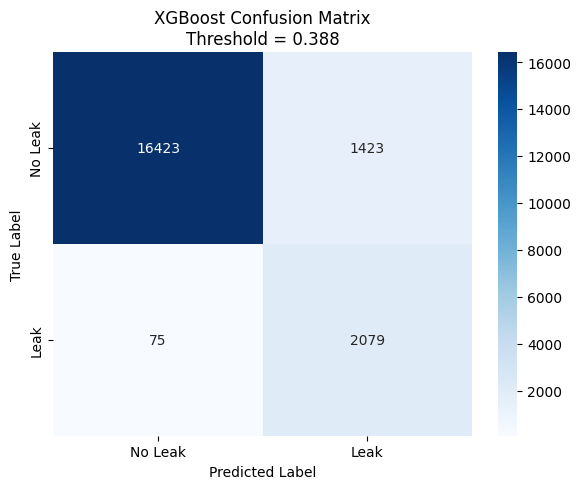

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


print(f"=== XGBoost (threshold={best_thr:.3f}) ===")


print(
    f"Accuracy: {acc:.4f}\n"
    f"Precision: {prec:.4f}\n"
    f"Recall: {rec:.4f}\n"
    f"F1: {f1:.4f}\n"
    f"ROC-AUC: {auc:.4f}\n"
    f"PR-AUC: {pr_auc:.4f}"
)

print("\nConfusion Matrix:")
print(cm)

# Visual Confusion Matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Leak', 'Leak'],
    yticklabels=['No Leak', 'Leak']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'XGBoost Confusion Matrix\nThreshold = {best_thr:.3f}')
plt.tight_layout()
plt.show()

#**saving**

In [18]:
model_path = os.path.join(
    OUTPUT_DIR,
    'xgboost_model.pkl'
)

joblib.dump(
    xgb_model,
    model_path
)

print("Model saved:")
print(model_path)

Model saved:
/content/xgboost_artifacts/xgboost_model.pkl


In [19]:
preprocessor_path = os.path.join(
    OUTPUT_DIR,
    'preprocessor.pkl'
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

print("Preprocessor saved:")
print(preprocessor_path)

Preprocessor saved:
/content/xgboost_artifacts/preprocessor.pkl


In [20]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

features_info = {
    "raw_input_features": X.columns.tolist(),
    "raw_input_feature_count": len(X.columns),

    "numerical_features": num_cols,
    "categorical_features": cat_cols,

    "processed_feature_names": feature_names.tolist(),
    "processed_feature_count": len(feature_names),

    "boolean_features_converted_to_int": bool_cols,

    "target": TARGET,

    "dropped_columns": drop_cols
}

features_path = os.path.join(
    OUTPUT_DIR,
    'feature_info.json'
)

with open(
    features_path,
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        features_info,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Feature information saved:")
print(features_path)

Feature information saved:
/content/xgboost_artifacts/feature_info.json


In [21]:
threshold_info = {
    "threshold": float(best_thr),
    "threshold_selection": "maximum F1 on validation set",
    "target": TARGET
}

threshold_path = os.path.join(
    OUTPUT_DIR,
    'threshold.json'
)

with open(
    threshold_path,
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        threshold_info,
        f,
        indent=4
    )

print("Threshold saved:")
print(threshold_path)

Threshold saved:
/content/xgboost_artifacts/threshold.json


In [22]:
metrics_info = {
    "threshold": float(best_thr),
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1": float(f1),
    "roc_auc": float(auc),
    "pr_auc": float(pr_auc),
    "confusion_matrix": cm.tolist(),
    "scale_pos_weight": float(scale_pos_weight),
    "random_state": RANDOM_STATE
}

metrics_path = os.path.join(
    OUTPUT_DIR,
    'xgboost_metrics.json'
)

with open(
    metrics_path,
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        metrics_info,
        f,
        indent=4
    )

print("Metrics saved:")
print(metrics_path)

Metrics saved:
/content/xgboost_artifacts/xgboost_metrics.json


In [23]:
res_df = pd.DataFrame(
    {
        'XGBoost': {
            'threshold': best_thr,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'roc_auc': auc,
            'pr_auc': pr_auc
        }
    }
).T

comparison_path = os.path.join(
    OUTPUT_DIR,
    'model_comparison2.csv'
)

res_df.to_csv(
    comparison_path,
    index=True
)

print(res_df.round(4))

print("\nSaved:")
print(comparison_path)

         threshold  accuracy  precision  recall      f1  roc_auc  pr_auc
XGBoost      0.388    0.9251     0.5937  0.9652  0.7351   0.9608  0.6106

Saved:
/content/xgboost_artifacts/model_comparison2.csv


In [24]:
training_code = r'''
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import xgboost as xgb


RANDOM_STATE = 42
TARGET = 'Leak_No_Leak'


df = pd.read_csv(
    '/content/aqua_grid_pfv_vibration_v2.csv'
)


leakage_cols = [
    'Leak_Type',
    'Leak_Type_Eligible'
]

future_target_cols = [
    'Failure_Next_7_Days',
    'Failure_Next_30_Days',
    'Failure_Next_90_Days'
]

id_date_cols = [
    'Pressure_Sensor_ID',
    'Flow_Sensor_ID',
    'Timestamp',
    'Observation_Date',
    'Installation_Date'
]

constant_cols = [
    'Pressure_Unit',
    'Flow_Unit'
]


groups = df['Asset_ID']


drop_cols = (
    leakage_cols
    + future_target_cols
    + id_date_cols
    + constant_cols
    + ['Asset_ID']
)


X = df.drop(
    columns=drop_cols + [TARGET]
)

y = df[TARGET].astype(int)


bool_cols = X.select_dtypes(
    include='bool'
).columns.tolist()

X[bool_cols] = X[bool_cols].astype(int)


cat_cols = (
    X.select_dtypes(
        include='object'
    ).columns.tolist()
    + [
        c for c in X.columns
        if str(X[c].dtype) == 'str'
    ]
)

cat_cols = list(
    dict.fromkeys(cat_cols)
)


num_cols = [
    c for c in X.columns
    if c not in cat_cols
]


gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

trainval_idx, test_idx = next(
    gss1.split(
        X,
        y,
        groups=groups
    )
)


X_trainval = X.iloc[trainval_idx]
X_test = X.iloc[test_idx]

y_trainval = y.iloc[trainval_idx]
y_test = y.iloc[test_idx]

groups_trainval = groups.iloc[
    trainval_idx
]


gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    gss2.split(
        X_trainval,
        y_trainval,
        groups=groups_trainval
    )
)


X_train = X_trainval.iloc[train_idx]
X_val = X_trainval.iloc[val_idx]

y_train = y_trainval.iloc[train_idx]
y_val = y_trainval.iloc[val_idx]


preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='if_binary'
            ),
            cat_cols
        )
    ]
)


X_train_proc = preprocessor.fit_transform(
    X_train
)

X_val_proc = preprocessor.transform(
    X_val
)

X_test_proc = preprocessor.transform(
    X_test
)


pos = y_train.sum()
neg = len(y_train) - pos

scale_pos_weight = neg / pos


model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)


model.fit(
    X_train_proc,
    y_train
)
'''


training_code_path = os.path.join(
    OUTPUT_DIR,
    'training_code.py'
)

with open(
    training_code_path,
    'w',
    encoding='utf-8'
) as f:
    f.write(training_code)


print("Training code saved:")
print(training_code_path)

Training code saved:
/content/xgboost_artifacts/training_code.py


In [25]:
inference_code = r'''
import pandas as pd
import numpy as np
import joblib
import json



# LOAD ARTIFACTS


model = joblib.load(
    'xgboost_model.pkl'
)

preprocessor = joblib.load(
    'preprocessor.pkl'
)


with open(
    'feature_info.json',
    'r',
    encoding='utf-8'
) as f:
    feature_info = json.load(f)


with open(
    'threshold.json',
    'r',
    encoding='utf-8'
) as f:
    threshold_info = json.load(f)


THRESHOLD = threshold_info['threshold']

EXPECTED_FEATURES = (
    feature_info['raw_input_features']
)



# INFERENCE FUNCTION


def detect(input_data):

    if isinstance(input_data, dict):

        input_data = pd.DataFrame(
            [input_data]
        )

    elif isinstance(input_data, pd.Series):

        input_data = input_data.to_frame().T

    elif not isinstance(input_data, pd.DataFrame):

        raise TypeError(
            "input_data must be a pandas "
            "DataFrame, Series, or dictionary."
        )



    # CHECK REQUIRED FEATURES


    missing_features = [
        c
        for c in EXPECTED_FEATURES
        if c not in input_data.columns
    ]

    if missing_features:

        raise ValueError(
            "Missing input features: "
            + str(missing_features)
        )



    # SAME FEATURE ORDER AS TRAINING


    X = input_data[
        EXPECTED_FEATURES
    ].copy()



    # BOOLEAN → INTEGER


    bool_cols = feature_info[
        'boolean_features_converted_to_int'
    ]

    existing_bool_cols = [
        c
        for c in bool_cols
        if c in X.columns
    ]

    X[existing_bool_cols] = (
        X[existing_bool_cols]
        .astype(int)
    )



    # SAME PREPROCESSING


    X_proc = preprocessor.transform(
        X
    )



    # XGBOOST PROBABILITY


    probability = (
        model.predict_proba(X_proc)[:, 1]
    )



    # SAME THRESHOLD


    prediction = (
        probability >= THRESHOLD
    ).astype(int)



    # FINAL LABEL


    detection = np.where(
        prediction == 1,
        'Leak',
        'No Leak'
    )


    return pd.DataFrame(
        {
            'Leak_Probability': probability,
            'Prediction': prediction,
            'Detection': detection
        }
    )
'''


# SAVE inference.py


inference_path = os.path.join(
    OUTPUT_DIR,
    'inference.py'
)

with open(
    inference_path,
    'w',
    encoding='utf-8'
) as f:
    f.write(inference_code)

print("Inference code saved successfully:")
print(inference_path)

Inference code saved successfully:
/content/xgboost_artifacts/inference.py


In [26]:

print("ALL XGBOOST ARTIFACTS")


for filename in sorted(
    os.listdir(OUTPUT_DIR)
):
    filepath = os.path.join(
        OUTPUT_DIR,
        filename
    )

    size = os.path.getsize(filepath)

    print(
        f"{filename:<30} "
        f"{size:,} bytes"
    )

ALL XGBOOST ARTIFACTS
feature_info.json              6,877 bytes
inference.py                   2,243 bytes
model_comparison2.csv          185 bytes
preprocessor.pkl               8,797 bytes
threshold.json                 129 bytes
training_code.py               2,906 bytes
xgboost_metrics.json           444 bytes
xgboost_model.pkl              1,150,128 bytes
